In [1]:
import pandas as pd
from binance.client import Client
import os
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.dates as mdates
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm

# ==========================================
# SETTINGS
# ==========================================
UPDATE_COIN_LIST = True  # True = Generate a new Top list. False = Read from the file.
COINS_FILE = "coins.txt"
TOP_N = 30               # How many coins to select

# Settings for downloading prices
TIMEFRAME = Client.KLINE_INTERVAL_30MINUTE
LOOKBACK = "30 days ago UTC"

# Initialization (API keys are not required for public data)
client = Client("", "")

# ==========================================
# BLOCK 1: COIN LIST MANAGEMENT
# ==========================================

if UPDATE_COIN_LIST:
    print(f"🔄 UPDATE mode. Scanning for Top-{TOP_N} coins by volume on Binance...")

    # 1. Get statistics
    tickers_stats = client.get_ticker()
    df_stats = pd.DataFrame(tickers_stats)

    # 2. Keep only USDT pairs
    df_stats = df_stats[df_stats['symbol'].str.endswith('USDT')]

    # 3. Convert volume to a numeric type
    df_stats['quoteVolume'] = df_stats['quoteVolume'].astype(float)

    # 4. FILTERING OUT UNWANTED ASSETS (IMPROVED LOGIC)
    # Stablecoins that we don't want at the top (Base currency)
    stablecoins = ('USDC', 'FDUSD', 'TUSD', 'DAI', 'BUSD', 'USDP', 'EUR')
    # Leveraged tokens (contain these substrings)
    leveraged = ['UP', 'DOWN', 'BEAR', 'BULL']

    # Filtering function
    def is_valid(symbol):
        # Remove the USDT suffix for checking
        base_asset = symbol[:-4]

        # 1. If the base is a stablecoin (e.g., USDCUSDT), remove it
        if base_asset.startswith(stablecoins):
            return False
        # 2. If it's a leveraged token (contains UP/DOWN), remove it
        if any(x in base_asset for x in leveraged):
            return False
        # 3. If it's USDT itself (USDTUSDT doesn't exist, but just in case)
        if base_asset == 'USDT':
            return False

        return True

    # Apply the filter
    mask = df_stats['symbol'].apply(is_valid)
    df_clean = df_stats[mask]

    # 5. Sort by quoteVolume and take the Top N
    top_coins = df_clean.sort_values(by='quoteVolume', ascending=False).head(TOP_N)

    ticker_list = top_coins['symbol'].tolist()

    # 6. Save to a file
    with open(COINS_FILE, 'w', encoding='utf-8') as f:
        for ticker in ticker_list:
            f.write(f"{ticker}\n")

    print(f"✅ New Top-{TOP_N} list saved to {COINS_FILE}")
    print(f"Leaders: {ticker_list[:5]}...")

else:
    print(f"📂 READ mode. Using the existing list from {COINS_FILE}")
    if not os.path.exists(COINS_FILE):
        print("❌ ERROR: File not found! Set UPDATE_COIN_LIST = True.")
        ticker_list = []
    else:
        with open(COINS_FILE, 'r') as f:
            ticker_list = [line.strip() for line in f if line.strip()]
        print(f"✅ Loaded {len(ticker_list)} coins from the file.")

# ==========================================
# BLOCK 2: DOWNLOADING DATA (FOR THIS LIST)
# ==========================================

if ticker_list:
    print(f"\n⬇️ Starting to download historical data for {len(ticker_list)} coins...")
    all_series = {}

    for symbol in ticker_list:
        try:
            # Download
            klines = client.get_historical_klines(symbol, TIMEFRAME, LOOKBACK)

            if not klines:
                print(f"   ⚠️ {symbol}: Empty response")
                continue

            # Parse
            temp_df = pd.DataFrame(klines, columns=[
                'time', 'open', 'high', 'low', 'close', 'vol',
                'close_time', 'q_vol', 'n', 'buy_base', 'buy_quote', 'ignore'
            ])

            temp_df['time'] = pd.to_datetime(temp_df['time'], unit='ms')
            temp_df.set_index('time', inplace=True)

            # Save the 'close' price series
            all_series[symbol] = temp_df['close'].astype(float)

            # A small progress indicator (a dot)
            print(".", end="")

        except Exception as e:
            print(f"   ❌ Error with {symbol}: {e}")

    # Assemble the final dataframe
    data = pd.DataFrame(all_series)

    # Data cleaning
    data = data.dropna(axis=1, how='all') # Remove columns that are entirely empty
    limit = 0.9 * len(data)
    data = data.dropna(axis=1, thresh=limit) # Remove columns with insufficient data
    data = data.ffill().dropna() # Forward-fill gaps and then drop any remaining NaNs at the beginning

    print(f"\n✅ DONE! Data matrix shape: {data.shape}")
    print("The 'data' variable is ready to be passed to PCA.")
else:
    print("The coin list is empty, nothing to download.")

🔄 UPDATE mode. Scanning for Top-30 coins by volume on Binance...
✅ New Top-30 list saved to coins.txt
Leaders: ['BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'XRPUSDT', 'PAXGUSDT']...

⬇️ Starting to download historical data for 30 coins...
..............................
✅ DONE! Data matrix shape: (1440, 28)
The 'data' variable is ready to be passed to PCA.


✅ Data found. Starting correlation calculation...
📊 Ready for analysis. Returns matrix shape: (1439, 28)


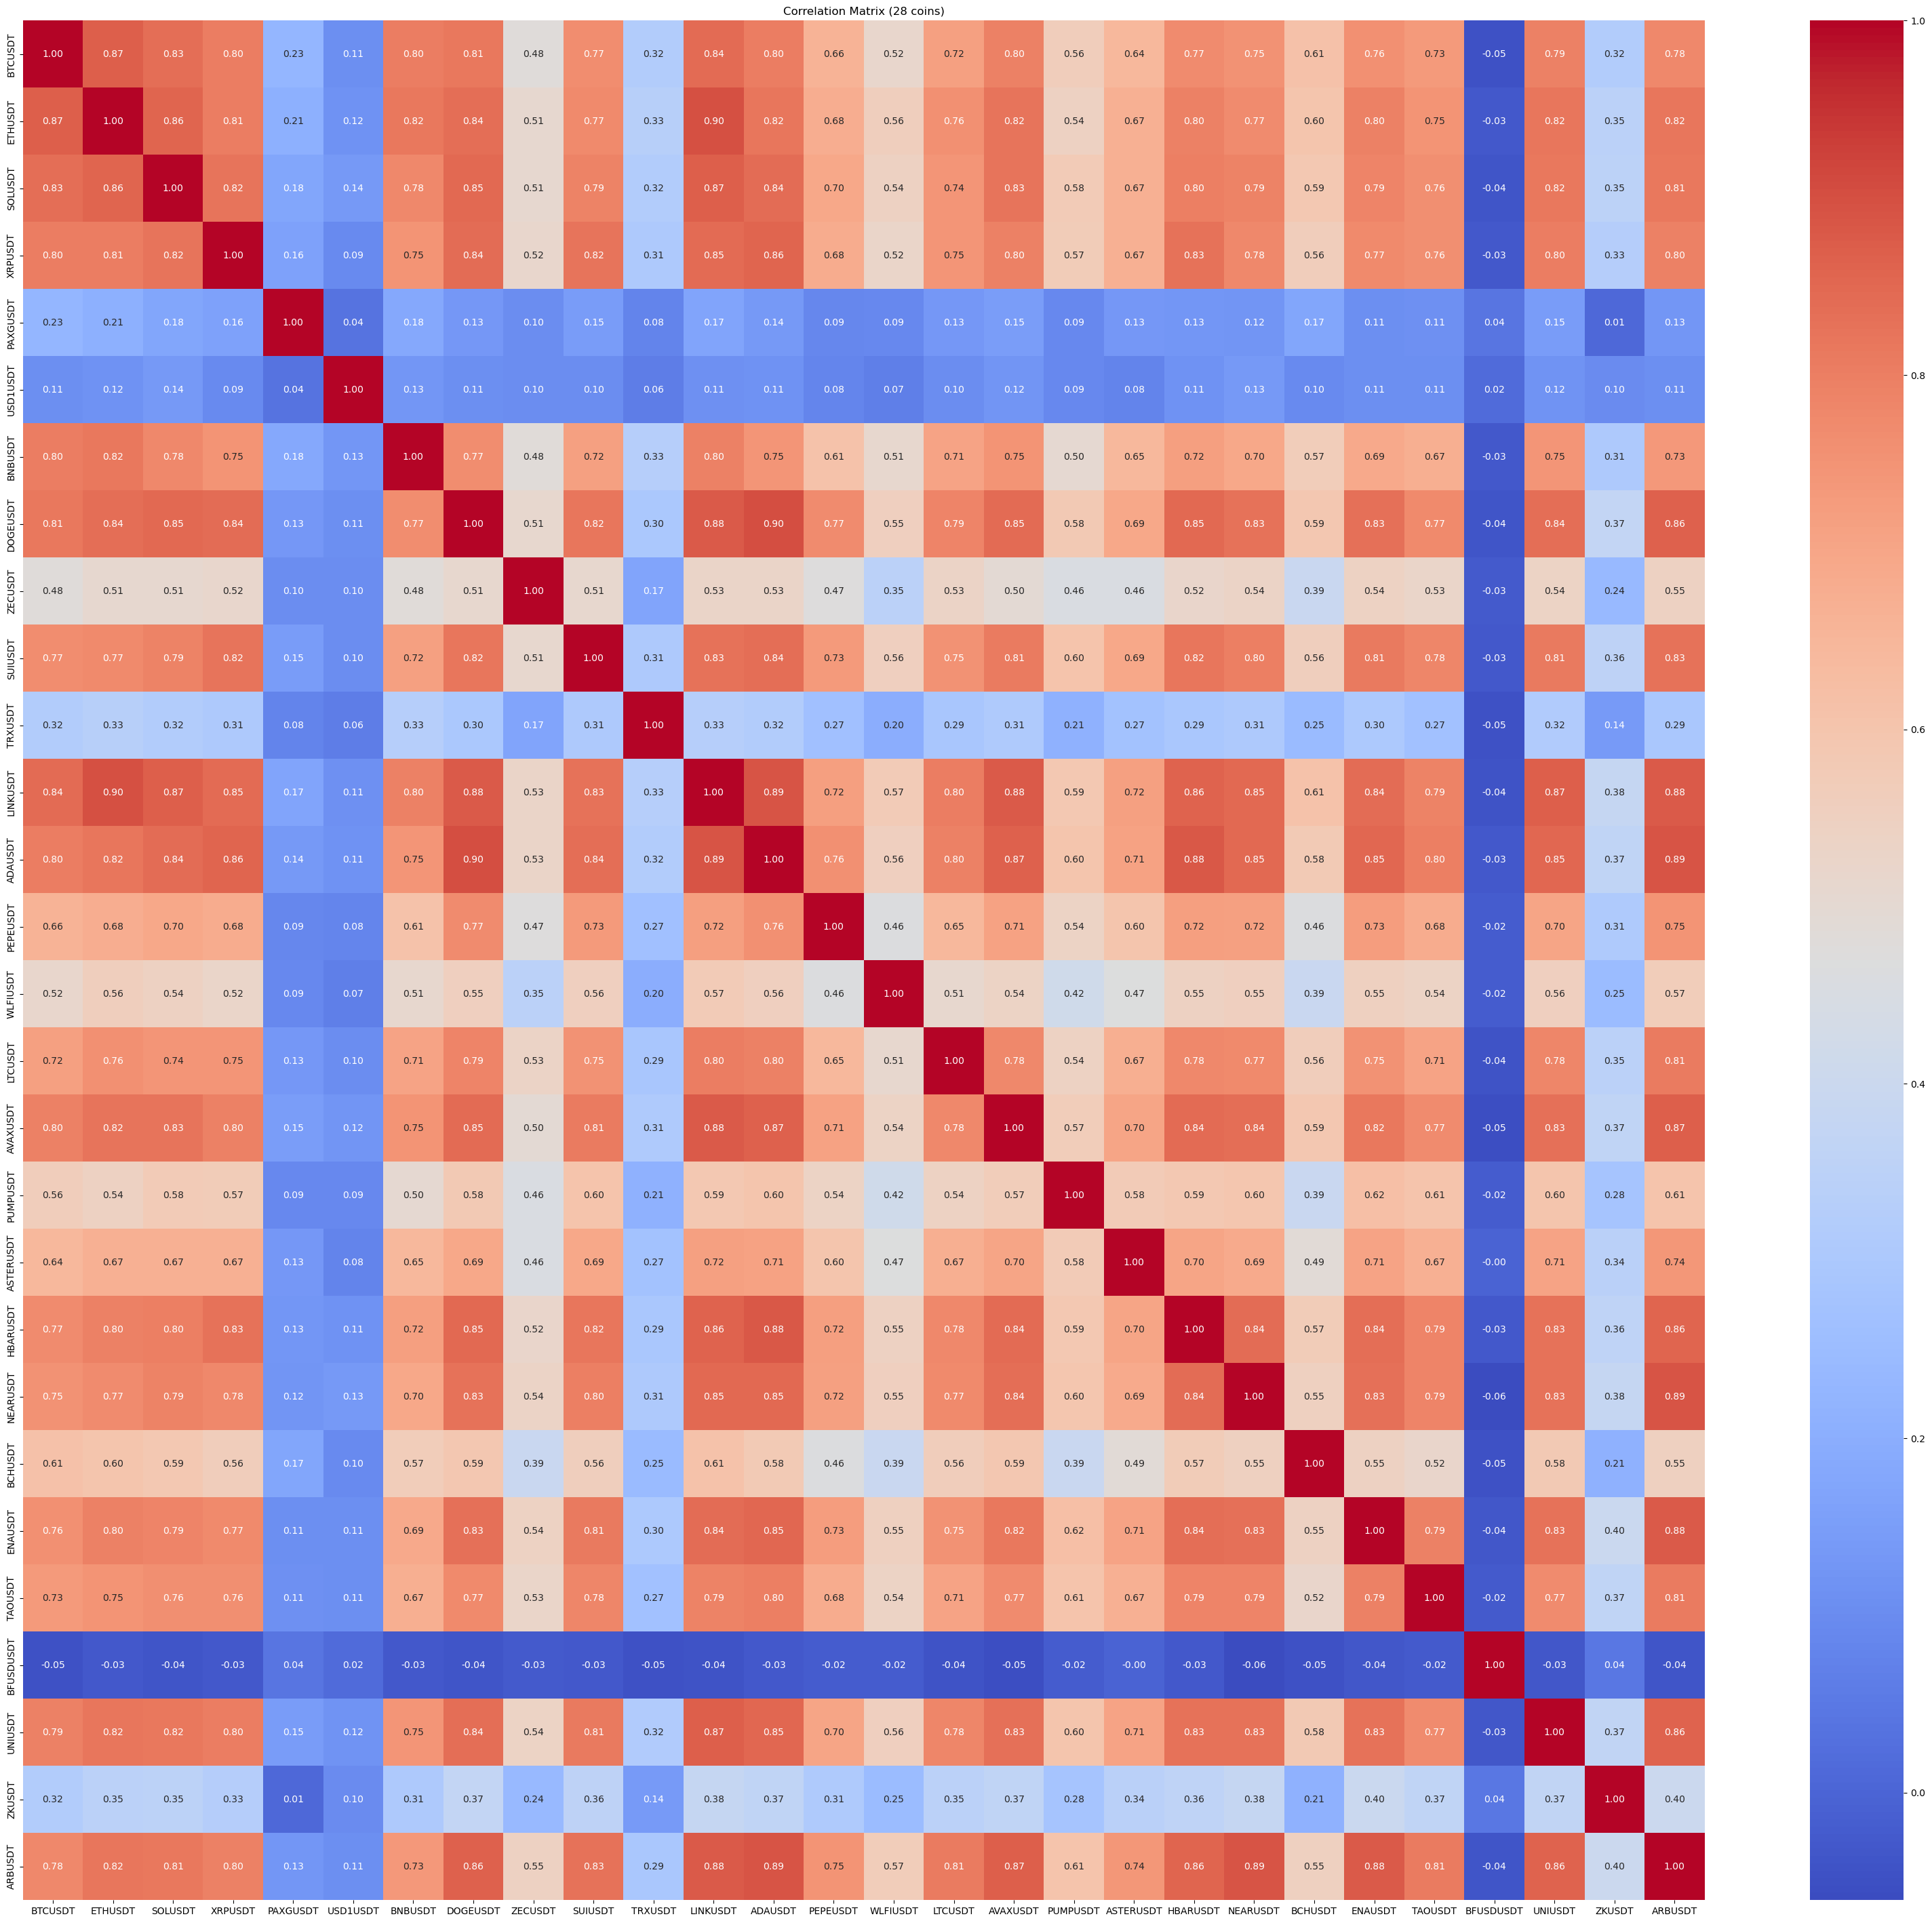

📊 Plotting performance since: 30 days ago UTC


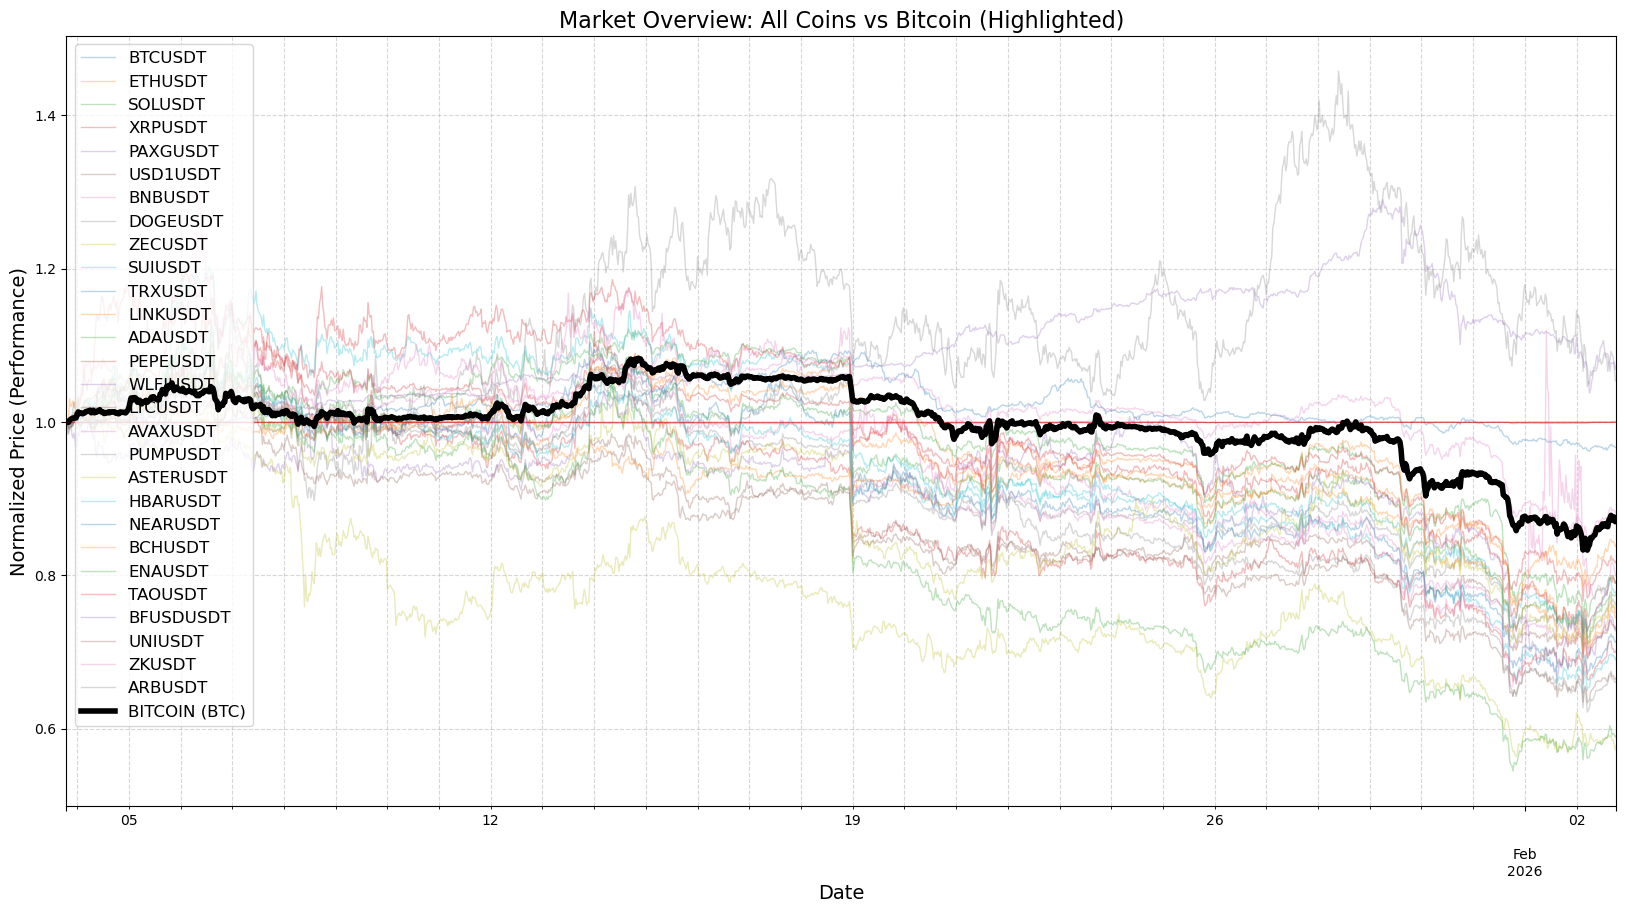

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Check in case the previous block failed to run
if 'data' not in locals() or data.empty:
    print("❌ ERROR: No data in the 'data' variable. Run the download block above!")
else:
    print("✅ Data found. Starting correlation calculation...")

    # 1. Calculate returns (Simple percentage change)
    # This creates the 'returns' variable that your next code block expects
    returns = data.pct_change().dropna()

    if returns.empty:
        print("❌ Error: The dataframe is empty after calculating returns (possibly not enough data).")
    else:
        print(f"📊 Ready for analysis. Returns matrix shape: {returns.shape}")

    # Create the heatmap plot
    plt.figure(figsize=(40, 36))
    sns.heatmap(returns.corr(), annot=True, cmap='coolwarm', fmt=".2f")
    plt.title(f"Correlation Matrix ({returns.shape[1]} coins)")
    plt.show()

# Plotting
print(f"📊 Plotting performance since: {LOOKBACK}")
df = data
# Normalize prices to start from 1.0 (100%)
normalized_price = df / df.iloc[0]

# 1. Create the figure and axis
fig, ax = plt.subplots(figsize=(20, 10))

# 2. Plot all coins with low opacity (alpha) and thin lines
normalized_price.plot(ax=ax, alpha=0.3, linewidth=1, legend=None)

# 3. Specifically highlight Bitcoin if it's in the list
btc_symbol = 'BTCUSDT'
if btc_symbol in normalized_price.columns:
    normalized_price[btc_symbol].plot(
        ax=ax, 
        color='black',   # Dark color to stand out
        linewidth=4,     # Make it much thicker
        label='BITCOIN (BTC)',
        zorder=10        # Ensure it's drawn on top of other lines
    )
    plt.legend(loc='upper left', fontsize=12)

plt.title("Market Overview: All Coins vs Bitcoin (Highlighted)", fontsize=16)
plt.ylabel('Normalized Price (Performance)', fontsize=14)
plt.xlabel('Date', fontsize=14)
plt.grid(True, which='both', linestyle='--', alpha=0.5)

# Optional: Add a horizontal line at 1.0 for reference
plt.axhline(1.0, color='red', linestyle='-', linewidth=0.8, alpha=0.5)

plt.show()

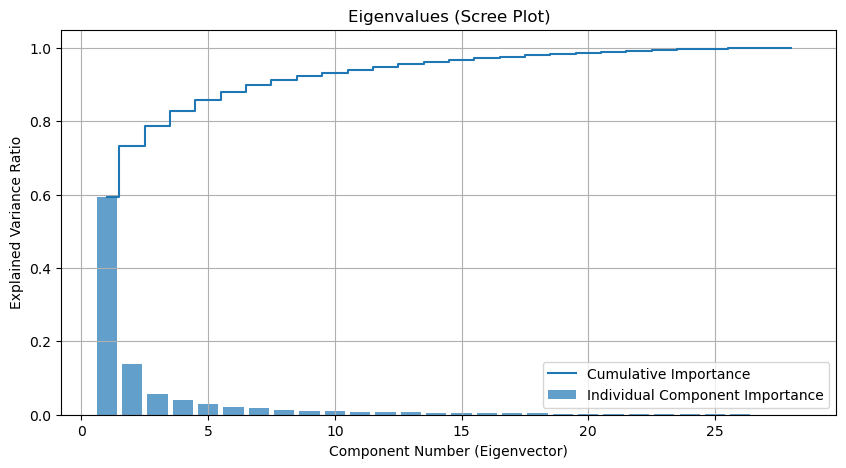

Importance of the 1st Component (Market): 59.34 %
Importance of the 2nd Component (Sector/Style): 13.87 %


In [11]:
# 1. Run PCA
# We want to find as many components as there are coins in our data
pca = PCA(n_components=len(returns.columns))
pca.fit(returns)

# 2. Analyze the "Importance" of components (Explained Variance)
# These are essentially the EIGENVALUES, but normalized (shown as percentages)
variance = pca.explained_variance_ratio_

# Plot the Scree Plot
plt.figure(figsize=(10, 5))
plt.bar(range(1, len(variance)+1), variance, alpha=0.7, align='center', label='Individual Component Importance')
plt.step(range(1, len(variance)+1), np.cumsum(variance), where='mid', label='Cumulative Importance')
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Component Number (Eigenvector)')
plt.legend(loc='best')
plt.title("Eigenvalues (Scree Plot)")
plt.grid(True)
plt.show()

# Print the numerical results
print("Importance of the 1st Component (Market):", round(variance[0] * 100, 2), "%")
print("Importance of the 2nd Component (Sector/Style):", round(variance[1] * 100, 2), "%")

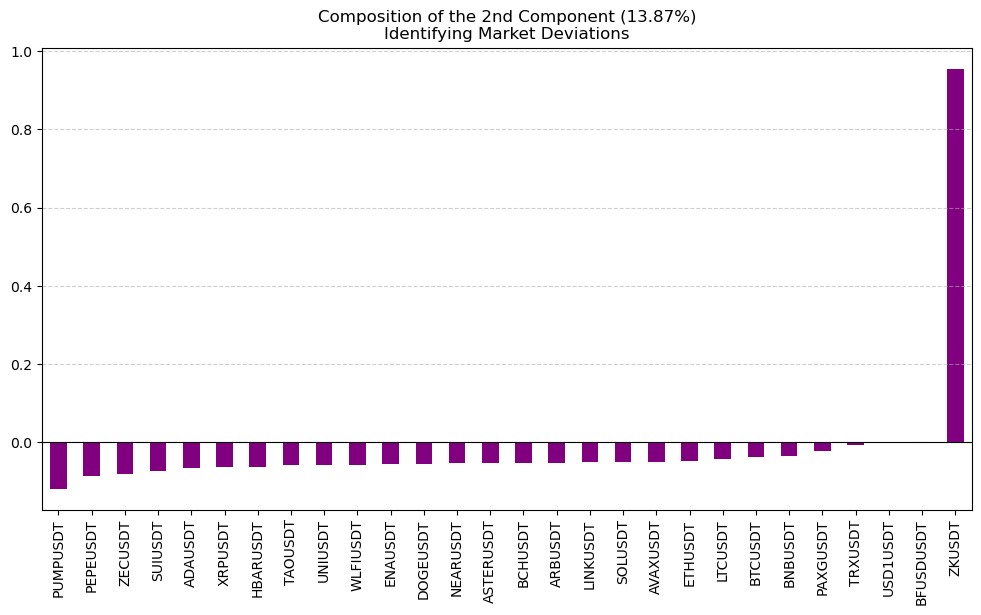

           PC1 (Market)  PC2 (Anomaly)
PUMPUSDT       0.309824      -0.117650
PEPEUSDT       0.244202      -0.084444
ZECUSDT        0.206813      -0.080533
SUIUSDT        0.230298      -0.072107
ADAUSDT        0.204148      -0.064589
XRPUSDT        0.170004      -0.062369
HBARUSDT       0.202712      -0.061603
TAOUSDT        0.229172      -0.058408
UNIUSDT        0.200599      -0.058016
WLFIUSDT       0.173884      -0.056932
ENAUSDT        0.251242      -0.054769
DOGEUSDT       0.191780      -0.054282
NEARUSDT       0.218474      -0.053427
ASTERUSDT      0.235127      -0.052897
BCHUSDT        0.109665      -0.052119
ARBUSDT        0.225890      -0.051946
LINKUSDT       0.181929      -0.051126
SOLUSDT        0.167416      -0.051102
AVAXUSDT       0.177350      -0.050441
ETHUSDT        0.157666      -0.048571
LTCUSDT        0.158646      -0.043384
BTCUSDT        0.101183      -0.037125
BNBUSDT        0.102297      -0.035653
PAXGUSDT       0.017670      -0.021645
TRXUSDT        0.024093  

In [13]:
# 1. Extract the eigenvectors (Loadings)
# pca.components_ is a matrix with dimensions [n_components, n_features]
pc1_loadings = pca.components_[0]
pc2_loadings = pca.components_[1]

# 2. Create a DataFrame for better visualization
loadings_df = pd.DataFrame({
    'PC1 (Market)': pc1_loadings,
    'PC2 (Anomaly)': pc2_loadings
}, index=returns.columns)

# 3. Sort by PC2 to observe polarity (identifying which assets move in opposite directions)
loadings_df = loadings_df.sort_values(by='PC2 (Anomaly)')

# 4. Plotting
plt.figure(figsize=(12, 6))
# Plot PC2 specifically to see outliers
loadings_df['PC2 (Anomaly)'].plot(kind='bar', color='purple')

plt.title(f"Composition of the 2nd Component ({round(variance[1] * 100, 2)}%)\nIdentifying Market Deviations")
plt.axhline(0, color='black', linewidth=0.8)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# Display the numerical data
print(loadings_df)

✅ Assets identified for deep analysis: ['ZKUSDT']

>>> COMPREHENSIVE REPORT: ZKUSDT vs BTC-USDT <<<
Global Beta: 1.8946 (Market Sensitivity)


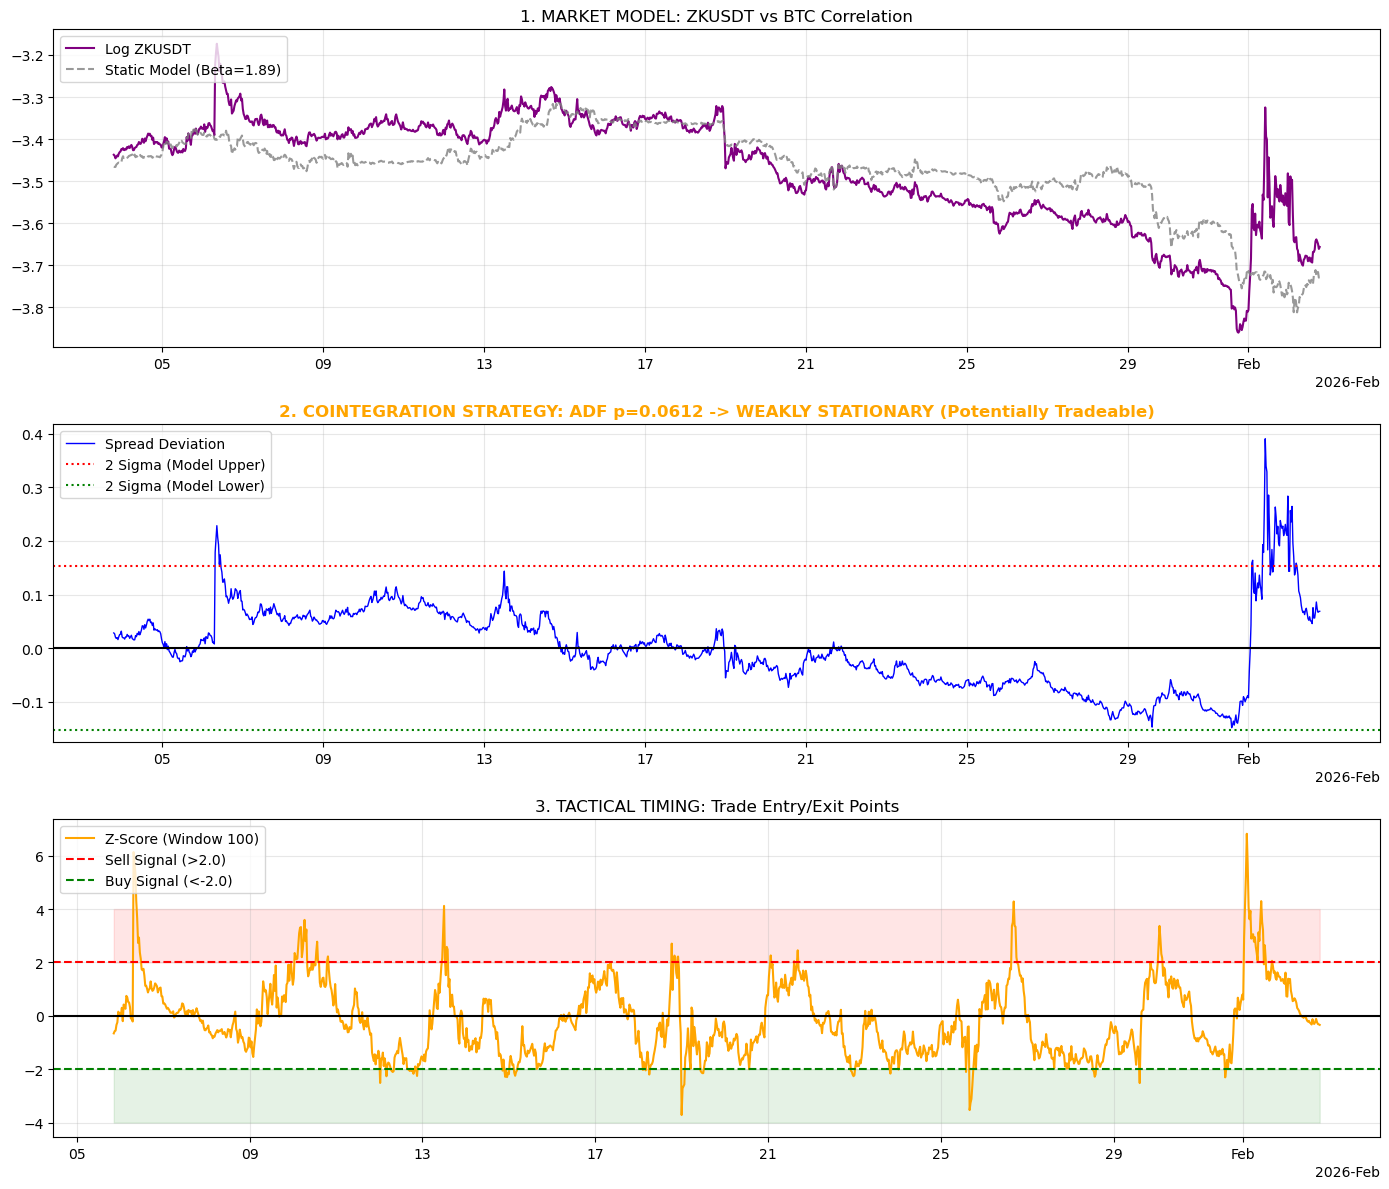

Analysis Completed. Final p-value: 0.0612


In [15]:
# ==========================================
# STEP 2: ECONOMETRIC ANALYSIS & VISUALIZATION
# ==========================================

# --- HYPERPARAMETERS (Magic Values) ---
ANOMALY_THRESHOLD = 0.4    # Threshold for PC2 loadings to identify "outlier" coins. 0.4 - default
Z_SCORE_WINDOW = 100       # Lookback period for tactical entry (rolling window). 100 - default
ADF_P_VALUE_CUTOFF = 0.05  # Statistical significance level for stationarity. 0.05 - default
Z_ENTRY_LEVEL = 2.0        # Standard deviation level for Buy/Sell signals. 2.0 - default

# Filter coins that show significant deviation from the market (based on PC2)
significant_coins = loadings_df[loadings_df['PC2 (Anomaly)'].abs() > ANOMALY_THRESHOLD]

if significant_coins.empty:
    print(f"❌ No significant anomalies found above threshold {ANOMALY_THRESHOLD}.")
else:
    target_list = significant_coins.index.tolist()
    print(f"✅ Assets identified for deep analysis: {target_list}")

    for coin in target_list:
        print(f"\n" + "="*70)
        print(f">>> COMPREHENSIVE REPORT: {coin} vs BTC-USDT <<<")
        
        # 1. DATA PREPARATION (Log-Transformation)
        # Using logarithms to linearize relationships and stabilize variance
        y = np.log(data[coin])
        x = np.log(data['BTCUSDT'])
        valid_idx = y.notna() & x.notna()
        y, x = y[valid_idx], x[valid_idx]

        # 2. BETA CALCULATION (Static / Global)
        # We calculate a constant Beta for the entire period to reveal structural mispricings
        beta, alpha = np.polyfit(x, y, 1)
        
        # Construct the Spread based on the static model
        spread = y - (beta * x + alpha)

        print(f"Global Beta: {beta:.4f} (Market Sensitivity)")

        # 3. STATIONARITY TEST (Augmented Dickey-Fuller)
        # We check if the spread is mean-reverting (returns to zero)
        try:
            # regression='c' includes a constant in the test
            adf_result = adfuller(spread.dropna(), regression='c')
            p_value = adf_result[1]
            
            if p_value < ADF_P_VALUE_CUTOFF:
                verdict, color_res = "STATIONARY (Ideal for Mean Reversion)", "green"
            elif p_value < 0.10:
                verdict, color_res = "WEAKLY STATIONARY (Potentially Tradeable)", "orange"
            else:
                verdict, color_res = "NON-STATIONARY (Trend-following Risk!)", "red"
        except Exception as e:
            print(f"ADF Test Error: {e}")
            p_value, verdict, color_res = 1.0, "ERROR", "black"

        # 4. TACTICAL Z-SCORE (Entry/Exit Timing)
        # We use a rolling window to normalize the spread and identify extremes
        z_rolling_mean = spread.rolling(window=Z_SCORE_WINDOW).mean()
        z_rolling_std = spread.rolling(window=Z_SCORE_WINDOW).std()
        z_score = (spread - z_rolling_mean) / z_rolling_std

        # 5. VISUALIZATION (Multi-panel Analysis)
        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), sharex=False)

        # PANEL 1: LOG-PRICES & MODEL
        ax1.plot(y, label=f'Log {coin}', color='purple', linewidth=1.5)
        # Plotting the "Fair Value" line based on the Bitcoin relationship
        ax1.plot(beta * x + alpha, label=f'Static Model (Beta={beta:.2f})', color='gray', linestyle='--', alpha=0.8)
        ax1.set_title(f"1. MARKET MODEL: {coin} vs BTC Correlation", fontsize=12)
        ax1.legend(loc='upper left')
        ax1.grid(True, alpha=0.3)

        # PANEL 2: GLOBAL SPREAD
        # Shows the raw deviation from the model's equilibrium
        ax2.plot(spread, color='blue', label='Spread Deviation', linewidth=1)
        ax2.axhline(0, color='black', linestyle='-')
        s_std = spread.std()
        ax2.axhline(2*s_std, color='red', linestyle=':', label='2 Sigma (Model Upper)')
        ax2.axhline(-2*s_std, color='green', linestyle=':', label='2 Sigma (Model Lower)')
        ax2.set_title(f"2. COINTEGRATION STRATEGY: ADF p={p_value:.4f} -> {verdict}", color=color_res, fontweight='bold')
        ax2.legend(loc='upper left')
        ax2.grid(True, alpha=0.3)

        # PANEL 3: TACTICAL Z-SCORE
        # Visualizing the momentum/reversion entry points
        clean_z = z_score.dropna()
        ax3.plot(clean_z, color='orange', label=f'Z-Score (Window {Z_SCORE_WINDOW})', linewidth=1.5)
        ax3.axhline(0, color='black', linestyle='-')
        ax3.axhline(Z_ENTRY_LEVEL, color='red', linestyle='--', label=f'Sell Signal (>{Z_ENTRY_LEVEL})')
        ax3.axhline(-Z_ENTRY_LEVEL, color='green', linestyle='--', label=f'Buy Signal (<-{Z_ENTRY_LEVEL})')
        ax3.fill_between(clean_z.index, Z_ENTRY_LEVEL, Z_ENTRY_LEVEL + 2, color='red', alpha=0.1)
        ax3.fill_between(clean_z.index, -Z_ENTRY_LEVEL, -Z_ENTRY_LEVEL - 2, color='green', alpha=0.1)
        ax3.set_title("3. TACTICAL TIMING: Trade Entry/Exit Points", fontsize=12)
        ax3.legend(loc='upper left')
        ax3.grid(True, alpha=0.3)

        # Date Formatting
        locator = mdates.AutoDateLocator(minticks=5, maxticks=15)
        formatter = mdates.ConciseDateFormatter(locator)
        for ax in [ax1, ax2, ax3]:
            ax.xaxis.set_major_locator(locator)
            ax.xaxis.set_major_formatter(formatter)

        plt.tight_layout()
        plt.show()
        print(f"Analysis Completed. Final p-value: {p_value:.4f}")

In [17]:
# ==========================================
# FINAL STEP: RISK ASSESSMENT & DESCRIPTIVE STATISTICS
# ==========================================

# This block is essential for Risk Management and Volatility analysis.
# We need these metrics to calculate position sizes and assess "tail risks".
stats = returns.describe()

print("\n--- Returns Statistics for Risk Management & Position Sizing ---")
# count: Ensures data consistency across all symbols (check for missing bars)
# mean:  The average expected return per timeframe (drift)
# std:   Volatility. Crucial for setting Stop-Loss levels and Vol-Targeting
# min:   Worst-case scenario (Tail Risk / Black Swan event)
# 25%:   Lower quartile - helps understand the distribution of negative returns
# 50%:   Median return (more robust than mean in skewed markets)
# 75%:   Upper quartile - helps understand the frequency of positive moves
# max:   Best-case scenario (Maximum historical upside)

print(stats)

# Optional: Highlighting the importance of Volatility (Standard Deviation)
# In professional finance, Std is the primary metric for the 'Risk' part of 'Risk/Reward'


--- Returns Statistics for Risk Management & Position Sizing ---
            BTCUSDT      ETHUSDT      SOLUSDT      XRPUSDT     PAXGUSDT  \
count  1.439000e+03  1439.000000  1439.000000  1439.000000  1439.000000   
mean  -9.016167e-05    -0.000185    -0.000149    -0.000125     0.000055   
std    3.184700e-03     0.004807     0.005060     0.005198     0.003235   
min   -2.212111e-02    -0.039204    -0.037022    -0.033505    -0.049247   
25%   -1.334704e-03    -0.001736    -0.002120    -0.002354    -0.000735   
50%   -1.109585e-07    -0.000103    -0.000072    -0.000094     0.000109   
75%    1.260262e-03     0.001620     0.001926     0.002060     0.001031   
max    1.738477e-02     0.032890     0.031437     0.029936     0.024317   

           USD1USDT      BNBUSDT     DOGEUSDT      ZECUSDT      SUIUSDT  ...  \
count  1.439000e+03  1439.000000  1439.000000  1439.000000  1439.000000  ...   
mean   7.909318e-09    -0.000079    -0.000169    -0.000342    -0.000230  ...   
std    1.258255e-0